In [ ]:
# Cell 1: imports + paths + device
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

save_dir = "/content/drive/MyDrive/6501-009/GP"
os.makedirs(save_dir, exist_ok=True)

latent_dim = 200

Mounted at /content/drive
cpu


In [ ]:
# Cell 2: models + load weights
class Encoder(nn.Module):
    def __init__(self, latent_dim=200):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=200):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


encoder = Encoder(latent_dim).to(device)
decoder = Decoder(latent_dim).to(device)
clf = Classifier().to(device)

encoder_path = f"{save_dir}/encoder.pt"
decoder_path = f"{save_dir}/decoder.pt"
clf_path = f"{save_dir}/classifier.pt"

encoder.load_state_dict(torch.load(encoder_path, map_location=device))
decoder.load_state_dict(torch.load(decoder_path, map_location=device))
clf.load_state_dict(torch.load(clf_path, map_location=device))

encoder.eval()
decoder.eval()
clf.eval()

print("models loaded")

models loaded


In [ ]:
# Cell 3: data + z2/z6 + helper functions
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

def get_digit(digit):
    for x, y in train_dataset:
        if y == digit:
            return x.unsqueeze(0)

x2 = get_digit(2).to(device)
x6 = get_digit(6).to(device)

with torch.no_grad():
    z2 = encoder(x2)
    z6 = encoder(x6)

def interpolate(z2, z6, alpha):
    return (1 - alpha) * z2 + alpha * z6

def total_variation(x):
    if x.dim() == 3:
        x = x.unsqueeze(0)
    tv_h = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean(dim=(1, 2, 3))
    tv_w = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean(dim=(1, 2, 3))
    return tv_h + tv_w

def reward_fn(x, beta=0.5, lambda_tv=0.08, lambda_off=0.40):
    single = (x.dim() == 3)
    if single:
        x_in = x.unsqueeze(0)
    else:
        x_in = x

    with torch.no_grad():
        logits = clf(x_in)
        probs = F.softmax(logits, dim=1)

    p2 = 1.1*probs[:, 2]
    p6 = 0.9*probs[:, 6]

    main = (p2 + p6) - beta * (p2 - p6) ** 2
    off = 1.0 - p2 - p6
    tv = total_variation(x_in)

    reward = main - lambda_tv * tv - lambda_off * off

    info = {
        "main": main.detach(),
        "off": off.detach(),
        "tv": tv.detach(),
        "p2": p2.detach(),
        "p6": p6.detach(),
        "pred": probs.argmax(dim=1).detach()
    }

    if single:
        reward = reward[0]
        info = {k: v[0] for k, v in info.items()}

    return reward, info

def compute_returns(rewards, gamma=0.95):
    """
    rewards: [T]
    """
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.stack(returns)

In [ ]:
# Cell 4: policy + rollout
class Policy(nn.Module):
    def __init__(self, dim, hidden=128, action_scale=2, init_std=0.6):
        super().__init__()
        self.action_scale = action_scale
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim)
        )
        self.log_std = nn.Parameter(torch.ones(dim) * np.log(init_std))

        self.log_std_min = -5
        self.log_std_max = -0.05

    def forward(self, z):
        mu = self.action_scale * torch.tanh(self.net(z))

        log_std = torch.clamp(
            self.log_std,
            min=self.log_std_min,
            max=self.log_std_max
        )

        std = torch.exp(log_std).unsqueeze(0).expand_as(mu)
        return mu, std

    def act(self, z, sample=True):
        mu, std = self.forward(z)
        dist = torch.distributions.Normal(mu, std)

        if sample:
            a = dist.rsample()
            logp = dist.log_prob(a).sum(dim=-1)
        else:
            a = mu
            logp = torch.zeros(z.shape[0], device=z.device)

        return a, logp, mu, std


policy = Policy(dim=latent_dim, hidden=128, action_scale=0.5).to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-4)

def rollout_episode(policy, z0, T, step_size, sample=True):
    z = z0.clone()
    logps = []
    rewards = []

    for t in range(T):
        action, logp, mu, std = policy.act(z, sample=sample)
        z = z + step_size * action

        with torch.no_grad():
            x = decoder(z)   # [1, 1, 28, 28]

        r, _ = reward_fn(x)

        logps.append(logp.squeeze())
        rewards.append(r.squeeze())

    logps = torch.stack(logps)      # [T]
    rewards = torch.stack(rewards)  # [T]

    return z, logps, rewards

In [ ]:
# Cell 5: train
num_epochs = 50
batch_size = 20
T = 10
step_size = 0.4
gamma = 0.90
print_every = 5

reward_history = []
loss_history = []

img_save_dir = f"{save_dir}/epoch_images"
os.makedirs(img_save_dir, exist_ok=True)

policy.train()

for epoch in range(num_epochs):
    batch_loss = 0.0
    batch_reward = 0.0
    last_z = None

    optimizer.zero_grad()

    for _ in range(batch_size):
        alpha0 = torch.tensor([0.6], device=device)
        z0 = interpolate(z2, z6, alpha0)

        z_final, logps, rewards = rollout_episode(
            policy=policy,
            z0=z0,
            T=T,
            step_size=step_size,
            sample=True
        )

        returns = compute_returns(rewards, gamma=gamma)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -(logps * returns.detach()).mean()
        loss.backward()

        batch_loss += loss.item()
        batch_reward += rewards.mean().item()
        last_z = z_final.detach()

    optimizer.step()

    batch_loss /= batch_size
    batch_reward /= batch_size

    loss_history.append(batch_loss)
    reward_history.append(batch_reward)

    with torch.no_grad():
        last_x = decoder(last_z)            # [1,1,28,28]
        _, info_dbg = reward_fn(last_x)
        last_img = last_x.squeeze().cpu()   # [28,28]

    plt.figure(figsize=(3, 3))
    plt.imshow(last_img, cmap="gray")
    plt.title(f"epoch={epoch}\nreward={batch_reward:.4f}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"{img_save_dir}/epoch_{epoch:03d}.png", dpi=150, bbox_inches="tight")
    plt.close()

    if epoch % print_every == 0:
        print(
            f"epoch={epoch}, "
            f"reward={batch_reward:.6f}, "
            f"loss={batch_loss:.6f}, "
            f"p2={info_dbg['p2'].item():.4f}, "
            f"p6={info_dbg['p6'].item():.4f}, "
            f"off={info_dbg['off'].item():.4f}, "
            f"tv={info_dbg['tv'].item():.4f}, "
            f"pred={info_dbg['pred'].item()}"
        )

epoch=0, reward=0.752320, loss=0.466141, p2=0.4333, p6=0.4192, off=0.1476, tv=0.1144, pred=6
epoch=5, reward=0.736011, loss=0.513015, p2=0.0735, p6=0.7903, off=0.1362, tv=0.1221, pred=6
epoch=10, reward=0.759236, loss=-0.420195, p2=0.1561, p6=0.7300, off=0.1139, tv=0.1269, pred=6
epoch=15, reward=0.729419, loss=1.049658, p2=0.0718, p6=0.7588, off=0.1694, tv=0.1238, pred=6
epoch=20, reward=0.688889, loss=0.331347, p2=0.0447, p6=0.8032, off=0.1522, tv=0.1153, pred=6
epoch=25, reward=0.715147, loss=0.603100, p2=0.6218, p6=0.3734, off=0.0048, tv=0.1234, pred=2
epoch=30, reward=0.759101, loss=-1.116118, p2=0.6895, p6=0.2868, off=0.0237, tv=0.1223, pred=2
epoch=35, reward=0.741832, loss=0.111333, p2=0.1338, p6=0.7357, off=0.1304, tv=0.1256, pred=6
epoch=40, reward=0.789687, loss=0.077491, p2=0.3283, p6=0.5190, off=0.1527, tv=0.1231, pred=6
epoch=45, reward=0.762725, loss=-0.281250, p2=0.2123, p6=0.6810, off=0.1067, tv=0.1301, pred=6


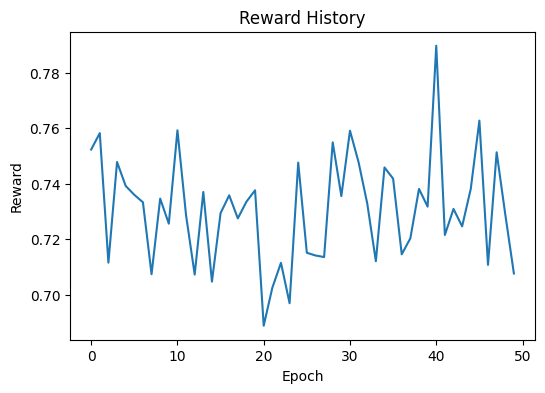

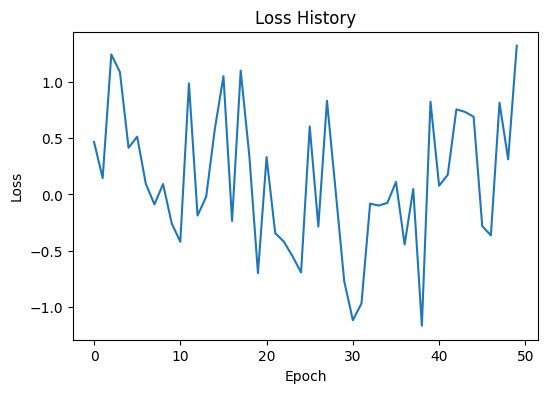

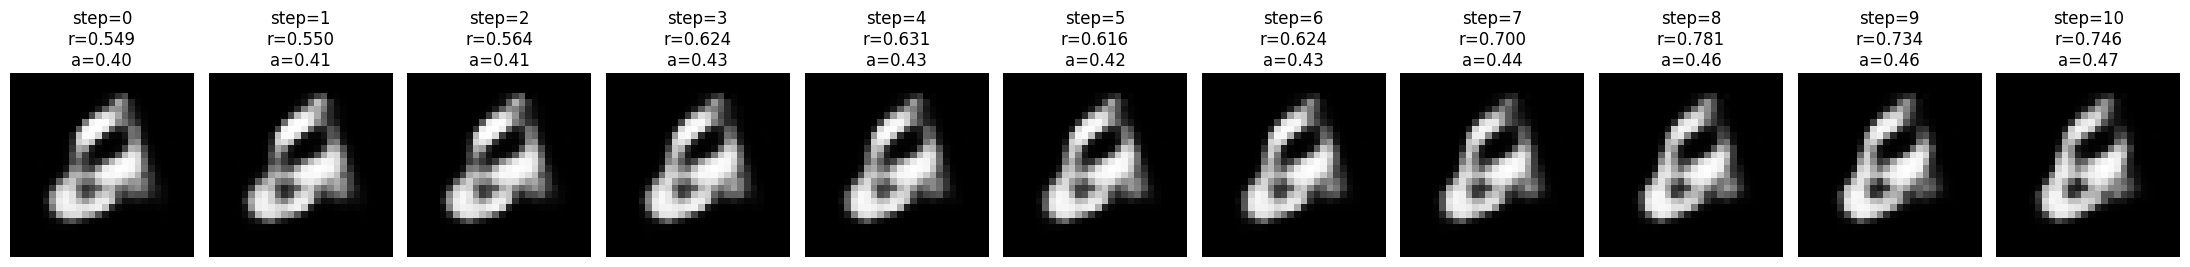

In [ ]:
# Cell 6: evaluation + plots
policy.eval()

alpha_test = torch.tensor([0.4], device=device)
z = interpolate(z2, z6, alpha_test)

direction = z6 - z2
direction_norm_sq = (direction * direction).sum(dim=-1, keepdim=True)

test_rewards = []
test_alphas = []
test_imgs = []

with torch.no_grad():
    for _ in range(11):
        x = decoder(z)
        r, _ = reward_fn(x)

        alpha_proj = ((z - z2) * direction).sum(dim=-1, keepdim=True) / (direction_norm_sq + 1e-8)

        test_rewards.append(r.item())
        test_alphas.append(alpha_proj.item())
        test_imgs.append(x.squeeze().cpu())

        a, _, _, _ = policy.act(z, sample=True)
        z = z + step_size * a

plt.figure(figsize=(6, 4))
plt.plot(reward_history)
plt.title("Reward History")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

fig, axes = plt.subplots(1, len(test_imgs), figsize=(2 * len(test_imgs), 2.5))
for i, ax in enumerate(axes):
    ax.imshow(test_imgs[i], cmap="gray")
    ax.set_title(f"step={i}\nr={test_rewards[i]:.3f}\na={test_alphas[i]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

,step,reward,pred,p2,p6,mu_mean,mu_abs_mean,mu_max_abs,std_mean,std_min,std_max,action_mean,action_abs_mean,action_max_abs,logp
0,0,0.516191,2,1.052328,0.002365,0.002130,0.072467,0.275002,0.600267,0.59977,0.600785,0.042754,0.487048,1.656546,-179.286102
1,1,0.522906,2,1.070317,0.002697,0.002580,0.072954,0.272267,0.600267,0.59977,0.600785,0.001388,0.483471,1.979472,-189.068588
2,2,0.520009,2,1.060034,0.002881,0.000738,0.075334,0.273687,0.600267,0.59977,0.600785,-0.061316,0.460993,1.615017,-174.835892
3,3,0.522362,2,1.067916,0.002863,0.000466,0.076452,0.261034,0.600267,0.59977,0.600785,-0.021969,0.417862,1.997299,-154.738892
4,4,0.522947,2,1.065551,0.003451,0.000146,0.078515,0.270908,0.600267,0.59977,0.600785,-0.019476,0.485725,1.368833,-175.616928
5,5,0.526383,2,1.063261,0.005097,-0.000295,0.079278,0.281240,0.600267,0.59977,0.600785,-0.042895,0.520227,1.797134,-195.669403
6,6,0.535480,2,1.072458,0.007587,-0.000930,0.079795,0.279669,0.600267,0.59977,0.600785,0.029569,0.494172,1.491651,-179.849701
7,7,0.532280,2,1.080060,0.005363,-0.000589,0.083919,0.283398,0.600267,0.59977,0.600785,-0.093598,0.458804,2.178838,-181.624741
8,8,0.538706,2,1.076702,0.008298,-0.000866,0.083536,0.287814,0.600267,0.59977,0.600785,-0.018983,0.489828,1.759109,-179.372162
9,9,0.538544,2,1.073445,0.008695,-0.000154,0.082985,0.287203,0.600267,0.59977,0.600785,-0.047573,0.545253,1.609753,-198.994110


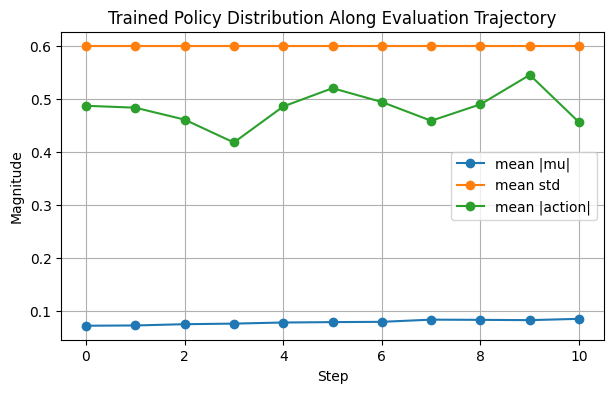

Learned log_std summary:
min log_std: -0.5112098455429077
max log_std: -0.5095185041427612
mean log_std: -0.5103811621665955
mean std: 0.600266695022583


In [ ]:
# Cell 7: Inspect trained policy distribution after training

policy.eval()

alpha_test = torch.tensor([0.3], device=device)
z = interpolate(z2, z6, alpha_test)

T_eval = 11

records = []

with torch.no_grad():
    for t in range(T_eval):
        # Current image and reward
        x = decoder(z)
        r, info = reward_fn(x)

        # Policy distribution at current z
        mu, std = policy.forward(z)

        # Sample one action from the learned stochastic policy
        dist = torch.distributions.Normal(mu, std)
        action = dist.sample()
        logp = dist.log_prob(action).sum(dim=-1)

        # Record summary statistics
        records.append({
            "step": t,
            "reward": r.item(),
            "pred": int(info["pred"].item()),
            "p2": info["p2"].item(),
            "p6": info["p6"].item(),
            "mu_mean": mu.mean().item(),
            "mu_abs_mean": mu.abs().mean().item(),
            "mu_max_abs": mu.abs().max().item(),
            "std_mean": std.mean().item(),
            "std_min": std.min().item(),
            "std_max": std.max().item(),
            "action_mean": action.mean().item(),
            "action_abs_mean": action.abs().mean().item(),
            "action_max_abs": action.abs().max().item(),
            "logp": logp.item()
        })

        # Move to next latent state
        z = z + step_size * action

# Convert to dataframe
import pandas as pd

df_policy = pd.DataFrame(records)
display(df_policy)

# Plot policy distribution summaries
plt.figure(figsize=(7, 4))
plt.plot(df_policy["step"], df_policy["mu_abs_mean"], marker="o", label="mean |mu|")
plt.plot(df_policy["step"], df_policy["std_mean"], marker="o", label="mean std")
plt.plot(df_policy["step"], df_policy["action_abs_mean"], marker="o", label="mean |action|")
plt.title("Trained Policy Distribution Along Evaluation Trajectory")
plt.xlabel("Step")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()

# Print the final learned global log_std parameter
if hasattr(policy, "log_std"):
    print("Learned log_std summary:")
    print("min log_std:", policy.log_std.min().item())
    print("max log_std:", policy.log_std.max().item())
    print("mean log_std:", policy.log_std.mean().item())
    print("mean std:", torch.exp(policy.log_std).mean().item())

elif hasattr(policy, "raw_log_std"):
    print("Policy uses raw_log_std parameterization.")

std summary
min std: 0.59976953
max std: 0.6007848
mean std: 0.60026675
median std: 0.60027236


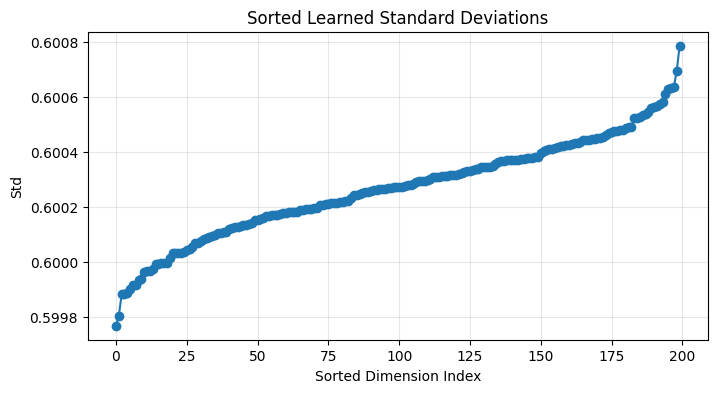

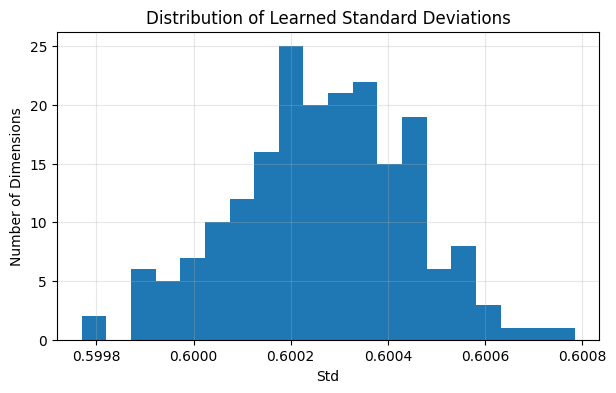

In [ ]:
# Cell 8: Visualize learned std across latent dimensions

import numpy as np

policy.eval()

with torch.no_grad():
    if hasattr(policy, "log_std"):
        log_std = policy.log_std.detach().cpu()
        std = torch.exp(policy.log_std).detach().cpu()
    elif hasattr(policy, "raw_log_std"):
        raw = policy.raw_log_std.detach()
        log_std = policy.log_std_min + 0.5 * (
            policy.log_std_max - policy.log_std_min
        ) * (torch.tanh(raw) + 1)
        log_std = log_std.detach().cpu()
        std = torch.exp(log_std).detach().cpu()
    else:
        raise ValueError("Policy does not have log_std or raw_log_std.")

std_np = std.numpy()
log_std_np = log_std.numpy()

print("std summary")
print("min std:", std_np.min())
print("max std:", std_np.max())
print("mean std:", std_np.mean())
print("median std:", np.median(std_np))


# 2. Sorted std plot
sorted_std = np.sort(std_np)

plt.figure(figsize=(8, 4))
plt.plot(sorted_std, marker="o")
plt.title("Sorted Learned Standard Deviations")
plt.xlabel("Sorted Dimension Index")
plt.ylabel("Std")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Histogram
plt.figure(figsize=(7, 4))
plt.hist(std_np, bins=20)
plt.title("Distribution of Learned Standard Deviations")
plt.xlabel("Std")
plt.ylabel("Number of Dimensions")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 9: Save

import pandas as pd


series_save_dir = f"{save_dir}/eval_series"
os.makedirs(series_save_dir, exist_ok=True)

series_name = "alpha0575_sample_true_run1"
series_dir = f"{series_save_dir}/{series_name}"
os.makedirs(series_dir, exist_ok=True)

# save single images
for i, img in enumerate(test_imgs):
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img, cmap="gray")
    plt.title(f"step={i}\nr={test_rewards[i]:.3f}\na={test_alphas[i]:.2f}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"{series_dir}/step_{i:02d}.png", dpi=150, bbox_inches="tight")
    plt.close()

# save series
fig, axes = plt.subplots(1, len(test_imgs), figsize=(2 * len(test_imgs), 2.5))

if len(test_imgs) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.imshow(test_imgs[i], cmap="gray")
    ax.set_title(f"step={i}\nr={test_rewards[i]:.3f}\na={test_alphas[i]:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{series_dir}/series_overview.png", dpi=200, bbox_inches="tight")
plt.close()

saved to: /content/drive/MyDrive/6501-009/GP/eval_series/alpha0575_sample_true_run1
